In [1]:
import xarray as xr
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr

col_m = sns.color_palette("Dark2")  
mod_color_dict = {"Basic": col_m[7],"Rep_M": col_m[1], "Rep_Z": col_m[4], "Rep_V": col_m[2]} 
model_order = ["Basic", "Rep_M", "Rep_Z"]

### Determine Noise level of dataset


In [2]:
tpm = pd.read_csv("data/White_Pauli_JN_BK/tpms_white_pauli_JN_BK.csv")
samples = pd.read_csv("data/White_Pauli_JN_BK/samples_white_pauli_JN_BK.csv")

meta = tpm[["ensembl_gene_id","ensembl_transcript_id","transcript_length","transcript_is_canonical","external_gene_name"]]
meta.to_csv("data/meta_data.csv", index=False)

tpm_long = tpm.melt(
    id_vars=["ensembl_gene_id", "ensembl_transcript_id", "transcript_length"],
    var_name="sample_id",
    value_vars=samples["sample_id"].unique(),
    value_name="tpm_values"
    )
#Merge with metadata
combined_df = tpm_long.merge(samples, on="sample_id", how="left")
combined_df.head()

agg = combined_df.groupby(["source", "time_hpf_standard", "ensembl_gene_id", "sample_id"])["tpm_values"].sum().reset_index()
agg_mean = (
    agg.groupby(["time_hpf_standard", "ensembl_gene_id", "source"], observed=True)
    .agg(
        tpm=("tpm_values", "mean"),))

dataset = agg_mean.to_xarray().rename({"time_hpf_standard": "time"}) 
dataset = dataset.assign_attrs(
    description="RNA-seq data from multiple sources: White et al. (2017), Pauli et al. (2011), BK, JN.",
    units="TPM")
dataset.head()

<xarray.Dataset>
Dimensions:          (time: 5, ensembl_gene_id: 5, source: 4)
Coordinates:
  * time             (time) float64 0.0 0.75 0.875 1.29 2.25
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * source           (source) object 'BK' 'JN' 'Pauli et al.' 'White et al.'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 nan nan ... 66.61
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

In [ ]:
agg.groupby(["source", "time_hpf_standard"])

,source,time_hpf_standard,ensembl_gene_id,sample_id,tpm_values
0,BK,1.29,ENSDARG00000000001,Dic_94_I,11.3928
1,BK,1.29,ENSDARG00000000001,Mix3_162_I,13.1790
2,BK,1.29,ENSDARG00000000001,Mix3_220_I,13.4145
3,BK,1.29,ENSDARG00000000001,Mix3_220_I-2,13.9037
4,BK,1.29,ENSDARG00000000001,Nap_250_I,13.7031
...,...,...,...,...,...
8996215,White et al.,120.00,ENSDARG00000117827,SAMEA3892044,0.0000
8996216,White et al.,120.00,ENSDARG00000117827,SAMEA3892045,0.0000
8996217,White et al.,120.00,ENSDARG00000117827,SAMEA3892046,0.0000
8996218,White et al.,120.00,ENSDARG00000117827,SAMEA3892047,0.0000


In [22]:
# check number of replicates per sample
rep_counts = (
    agg.groupby(["source", "time_hpf_standard"])["sample_id"]
    .nunique()
    .reset_index(name="n_replicates")
)
rep_counts.pivot(index="time_hpf_standard", columns="source", values="n_replicates")

source,BK,JN,Pauli et al.,White et al.
time_hpf_standard,,,,
0.000,NaN,NaN,NaN,5.0
0.750,NaN,NaN,NaN,5.0
0.875,NaN,NaN,2.0,NaN
1.290,5.0,NaN,NaN,NaN
2.250,NaN,NaN,NaN,5.0
2.580,4.0,2.0,NaN,NaN
3.000,NaN,NaN,2.0,5.0
4.300,NaN,NaN,NaN,5.0
4.330,NaN,NaN,2.0,NaN


In [33]:
rep_counts[rep_counts["n_replicates"] > 2].value_counts("source")

source
BK              20
White et al.    18
JN               5
Pauli et al.     1
Name: count, dtype: int64

In [ ]:
agg_stats = (
    agg.groupby(["time_hpf_standard", "ensembl_gene_id", "source"], observed=True)
    .agg(
        tpm=("tpm_values", "mean"),
        tpm_std=("tpm_values", "std"),
        n_reps=("tpm_values", "count"),
    )
)
agg_stats["tpm_cv"] = agg_stats["tpm_std"] / agg_stats["tpm"]  # coefficient of variation
ds = agg_stats.to_xarray()
ds

common_mask = (ds['n_reps'] >= 3)  # drop n=1,2 timepoints where CV is undefined or unstable
cv_filtered = ds['tpm_cv'].where(common_mask)
cv_source_filtered = cv_filtered.mean(dim='time_hpf_standard', skipna=True).median(dim='ensembl_gene_id')
cv_source_filtered

cv_q90 = cv_filtered.mean(dim='time_hpf_standard', skipna=True).quantile(0.9, dim='ensembl_gene_id')
cv_q90

<xarray.Dataset>
Dimensions:            (time_hpf_standard: 50, ensembl_gene_id: 36570, source: 4)
Coordinates:
  * time_hpf_standard  (time_hpf_standard) float64 0.0 0.75 ... 103.2 120.0
  * ensembl_gene_id    (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENS...
  * source             (source) object 'BK' 'JN' 'Pauli et al.' 'White et al.'
Data variables:
    tpm                (time_hpf_standard, ensembl_gene_id, source) float64 n...
    tpm_std            (time_hpf_standard, ensembl_gene_id, source) float64 n...
    n_reps             (time_hpf_standard, ensembl_gene_id, source) float64 n...
    tpm_cv             (time_hpf_standard, ensembl_gene_id, source) float64 n...

In [40]:
data = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
df = pd.read_csv("results/results_summary/params_combined.csv")

df_out = df[(df["t_reg_mean"] > 120)]
df_out.value_counts("model")

#genes =df.gene_id.values
#for g in genes:
    #plt.figure()
    #plt.plot(data.time, data.sel(ensembl_gene_id=g).tpm, "o-")

model
Rep_M    12
Rep_Z     2
Name: count, dtype: int64

In [68]:
print(data)

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 36570, time: 50, source: 4)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 96.0 103.2 120.0
  * source           (source) object 'BK' 'JN' 'Pauli' 'White'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 nan nan ... 0.0
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM


In [13]:
df["t_m_half"] = np.log(2) / df["delta_m_mean"]
df["t_z_half"] = np.log(2) / df["delta_z_mean"]

df = df[df["t_reg_mean"] < 120.0]

sub_m = df[df["model"] == "Rep_M"].copy()
sub_z = df[df["model"] == "Rep_Z"].copy()

In [ ]:
ds_params = pd.read_csv("results/results_summary/params_combined.csv")
ds_params

df = ds_params[ds_params["model"] != "Basic" ].copy()

df["r"] = df["beta_mean"] / df["alpha_mean"]

df["t_half_m"] = np.log(2) / df["delta_m_mean"]
df["t_half_m"] = np.log(2) / df["delta_m_mean"]


df = df[df["r"] > 1e-5]

param_cluster = df[["gene_id", "model", "r", "t_zga_mean", "t_rep_mean"]].copy()

import numpy as np

param_cluster["t_zga"] = np.minimum(param_cluster["t_zga_mean"],  param_cluster["t_rep_mean"])
param_cluster["t_reg"] = np.maximum(param_cluster["t_zga_mean"],  param_cluster["t_rep_mean"])

param_cluster.loc[param_cluster["r"] > 1, "dir"] = "up"
param_cluster.loc[param_cluster["r"] == 1, "dir"] = "none"
param_cluster.loc[param_cluster["r"] < 1, "dir"] = "down"


param_cluster.loc[param_cluster["t_zga"] < 2, "activation"] = "early"
param_cluster.loc[(param_cluster["t_zga"] <= 4) & (param_cluster["t_zga"] >= 2) , "activation"] = "zga"
param_cluster.loc[param_cluster["t_zga"] > 4, "activation"] = "late"

#param_cluster.loc[param_cluster["t_reg_mean"] < 2, "activation"] = "early"
#param_cluster.loc[(param_cluster["t_reg_mean"] <= 4) & (param_cluster["t_zga_mean"] >= 2) , "activation"] = "zga"
#param_cluster.loc[param_cluster["t_reg_mean"] > 4, "activation"] = "late"

param_cluster

,gene_id,model,r,t_zga_mean,t_rep_mean,t_zga,t_reg,dir,activation
22530,ENSDARG00000000001,Rep_M,0.103700,0.371,2.73,0.371,2.73,down,early
22531,ENSDARG00000000002,Rep_M,1.038095,15.000,33.60,15.000,33.60,up,late
22532,ENSDARG00000000018,Rep_M,0.061503,0.426,2.39,0.426,2.39,down,early
22533,ENSDARG00000000019,Rep_M,0.353435,11.500,17.60,11.500,17.60,down,late
22534,ENSDARG00000000068,Rep_M,0.174372,0.517,4.28,0.517,4.28,down,late
...,...,...,...,...,...,...,...,...,...
67585,ENSDARG00000117792,Rep_Z,0.000640,0.782,4.22,0.782,4.22,down,late
67586,ENSDARG00000117808,Rep_Z,0.577419,2.570,17.70,2.570,17.70,down,late
67587,ENSDARG00000117812,Rep_Z,0.788520,5.350,14.40,5.350,14.40,down,late
67588,ENSDARG00000117815,Rep_Z,0.178390,6.110,10.70,6.110,10.70,down,late


In [14]:
gof_src = pd.read_csv("results/results_summary/gof_src_combined.csv")
gof_src.head()

,gene_id,model,source,BIC,AIC,WAIC,LOO,rho,pearsonr,NRMSE,MASE,accepted,supercluster,supercluster_no,subcluster_no
0,ENSDARG00000000001,Basic,BK,43.276070,37.540001,-47.244569,-47.368093,-0.449918,0.642359,0.210414,0.861284,False,SD,0,0
1,ENSDARG00000000001,Basic,JN,21.126389,15.390320,-47.244569,-47.368093,-0.023810,0.822369,0.312594,0.831596,False,SD,0,0
2,ENSDARG00000000001,Basic,Pauli,30.327650,24.591581,-47.244569,-47.368093,0.833333,0.558843,0.341746,0.815769,False,SD,0,0
3,ENSDARG00000000001,Basic,White,41.197548,35.461479,-47.244569,-47.368093,0.393189,0.507580,0.313140,0.769244,False,SD,0,0
4,ENSDARG00000000002,Basic,BK,28.937088,23.201019,-35.081911,-35.113083,0.982485,0.982436,0.120844,0.318856,True,DSU,3,2


In [16]:
NRMSE_thres = 0.3
RHO_thres = 0.7

cluster_order = ["SD", "DSD", "SU", "DSU"]
cluster_names = {0 : "SD", 1 : "DSD", 2 : "SU", 3 : "DSU"}
col_c = sns.color_palette("Set1", n_colors=4)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], }

col_m = sns.color_palette("Dark2")  
mod_color_dict = {"Basic": col_m[7],"Rep_M": col_m[1], "Rep_Z": col_m[3], "Rep_V": col_m[4]} 
model_order = ["Basic", "Rep_M", "Rep_Z"]

col_s = sns.color_palette("twilight_shifted")  
src_color_dict =  {'White':col_s[0], 'Pauli':col_s[1], 'JN':col_s[4], 'BK':col_s[5]}


In [11]:
model_name = "Rep_M"
hue_key = "source"
merged = (gof_src[gof_src["model"] == model_name]).sort_values(["supercluster_no", "gene_id"])
cluster_order = merged.supercluster.dropna().unique()

sources = merged.source.unique()

# Load original data
accepted = merged[(merged["rho"] > RHO_thres) & (merged["NRMSE"] < NRMSE_thres) ]

count_model = accepted[hue_key].value_counts()
count_cluster = accepted.groupby("supercluster")["gene_id"].nunique()

merged_counts = merged.groupby([hue_key, "supercluster"]).size().reset_index(name="merged")
accepted_counts = accepted.groupby([hue_key, "supercluster"]).size().reset_index(name="accepted")
result = pd.merge(merged_counts, accepted_counts, how="left", on=[hue_key, "supercluster"])


## Cluster GOF

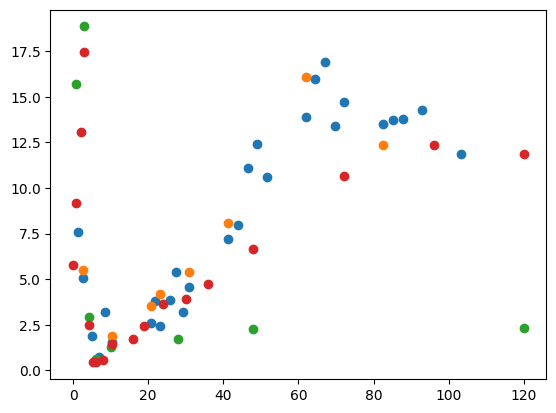

In [22]:
ds0 = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
#ds0.sel(source="BK").dropna(dim="time", how="all", subset=["tpm"])
ds = ds0.sel(ensembl_gene_id="ENSDARG00000000189")

plt.plot(ds.time, ds.tpm, "o")

In [53]:
ds0 - ds0.mean(dim=("time", "source")) / ds0.std(dim=("time", "source"))

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 36570, time: 50, source: 4)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 96.0 103.2 120.0
  * source           (source) object 'BK' 'JN' 'Pauli' 'White'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 nan nan ... -0.3111

In [111]:
ds0 = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")

t_not = [5.16, 8.6, 27.52, 41.28]
mask = ds0.time.isin(t_not)
ds0.sel(time=mask)

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 36570, time: 4, source: 4)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 5.16 8.6 27.52 41.28
  * source           (source) object 'BK' 'JN' 'Pauli' 'White'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 1.275 nan ... nan
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

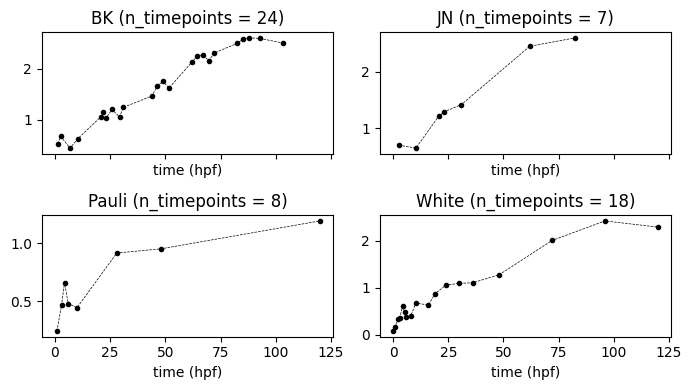

In [106]:
ds0 = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")

t_not = [5.16, 8.6, 27.52, 41.28]
mask = ~ds0.time.isin(t_not)
ds0 = ds0.sel(time=mask)

fig, ax = plt.subplots(2,2, figsize=(7, 4), sharex=True)
ax = ax.flatten()

for x, src in enumerate(ds0.source.values):
    ds = ds0.sel(source=src)
    ds = ds.dropna(dim="time", how="all", subset=["tpm"])
    #print(np.isnan(ds["tpm"].values).sum())
    ax[x].plot(ds.time, ds.tpm.median(dim="ensembl_gene_id"), ".--", c="k", lw=0.5)
    ax[x].set(title=f"{src} (n_timepoints = {len(ds.time)})", xlabel="time (hpf)")
plt.tight_layout()

In [39]:
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds_clean = ds.dropna(dim="time", how="all", subset=["tpm"])
mask = (ds_clean.tpm.max(dim="time", skipna=True) >= 1).all(dim="source")
ds["tpm"] = np.log2(ds.tpm + 1)
ds["tpm"] = (ds.tpm - ds.tpm.mean(dim=("time", "source"))) / ds.tpm.std(dim=("time", "source"))

ds_filtered = ds.sel(ensembl_gene_id=mask)

traj120 = xr.load_dataarray("clustering/results/all_gene_trajectories_120.nc")
gof120 = pd.read_csv("clustering/results/gof_trajectories_120.csv")

gof120["accepted_r"] = gof120["pearson"] > 0.5
gof120["accepted_rho"] = gof120["spearman"] > 0.5

print("n genes: ",(gof120.ensembl_gene_id.nunique()))
#gof120.groupby("source").sum("accepted") / gof120.groupby("source").count().drop(columns="ensembl_gene_id")
gof120.groupby("source").mean("accepted")

n genes:  23428


,nrmse,pearson,spearman,accepted,accepted_r,accepted_rho
source,,,,,,
BK,0.132616,0.872871,0.815204,0.903833,0.957444,0.930681
JN,0.165447,0.906401,0.831667,0.842966,0.960944,0.917449
Pauli,0.222959,0.809944,0.756495,0.755122,0.896790,0.875662
White,0.163626,0.827784,0.776410,0.855301,0.905882,0.886034


<Axes: xlabel='spearman', ylabel='Density'>

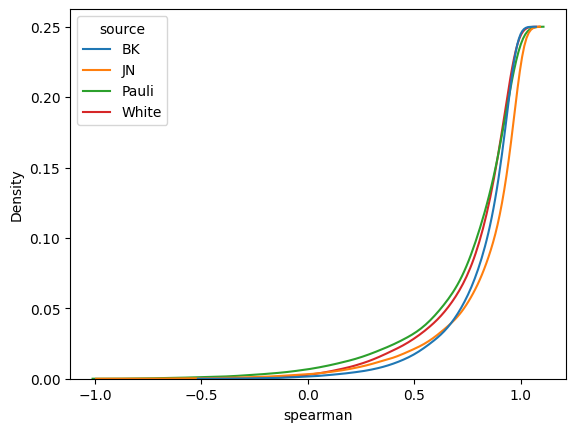

In [40]:
sns.kdeplot(gof120, x="spearman", hue="source", log_scale=False, cumulative=True)

<Axes: xlabel='pearson', ylabel='Density'>

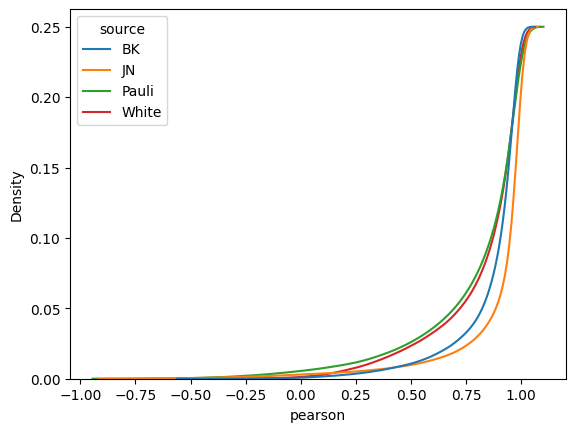

In [41]:
sns.kdeplot(gof120, x="pearson", hue="source", log_scale=False, cumulative=True)

<Axes: xlabel='nrmse', ylabel='Density'>

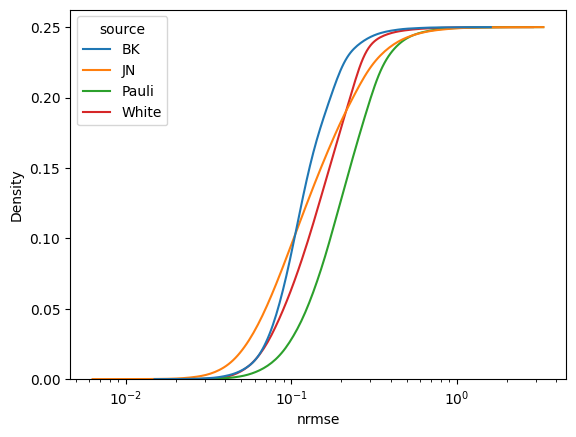

In [42]:
sns.kdeplot(gof120, x="nrmse", hue="source", log_scale=True, cumulative=True)

Mean NRMSE:  source
BK       0.132616
JN       0.165447
Pauli    0.222959
White    0.163626
Name: nrmse, dtype: float64 



<Axes: title={'center': 'Accepted NRMSE by Source (120h)'}, ylabel='Source'>

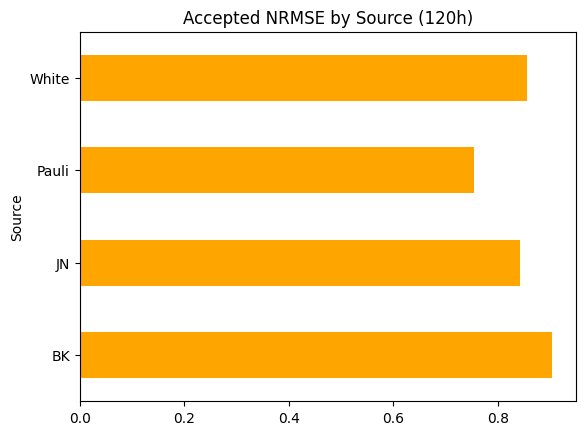

In [43]:
print("Mean NRMSE: ", gof120.groupby("source").nrmse.mean(), "\n")
gof120.groupby("source").nrmse.mean().plot.barh(color="orange", ylabel="Source", y="Mean NRMSE", title="Mean NRMSE by Source (120h)")
plt.close()
gof120.groupby("source").accepted.mean().plot.barh(color="orange", ylabel="Source", y="% accepted", title="Accepted NRMSE by Source (120h)")

In [44]:
gene_sums = gof120.groupby("ensembl_gene_id").sum("accepted")
accepted_genes = gene_sums[gene_sums["accepted"] > 0].index.to_list()
rejected_genes = gene_sums[gene_sums["accepted"] == 0].index.to_list()
print(len(accepted_genes))
print(len(rejected_genes))

22530
898


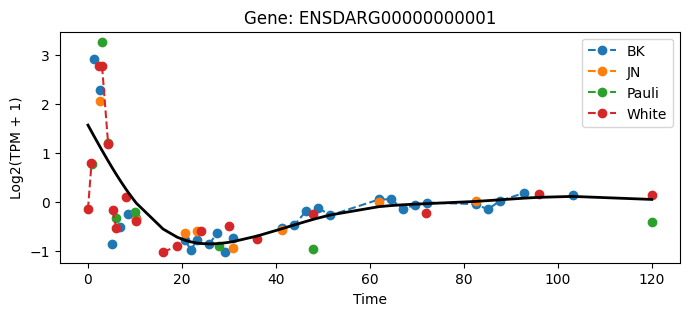

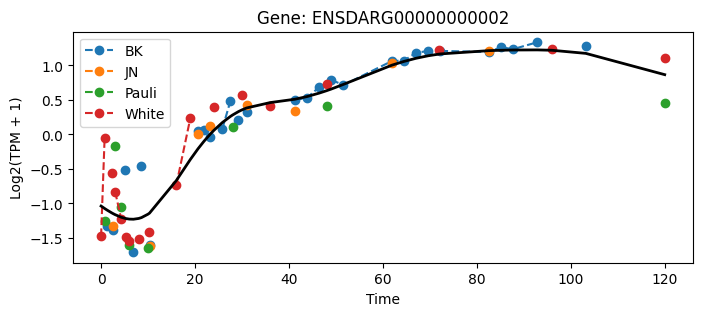

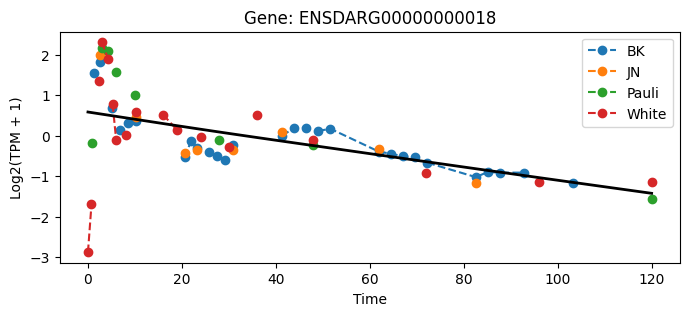

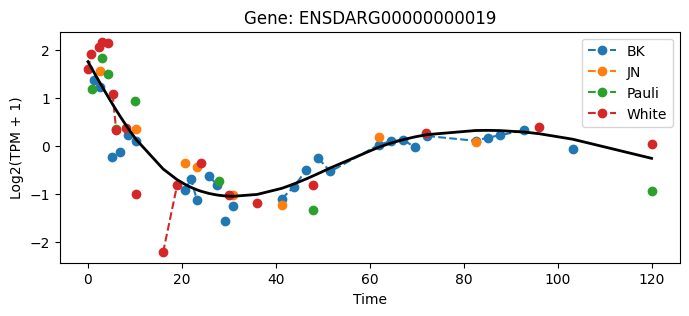

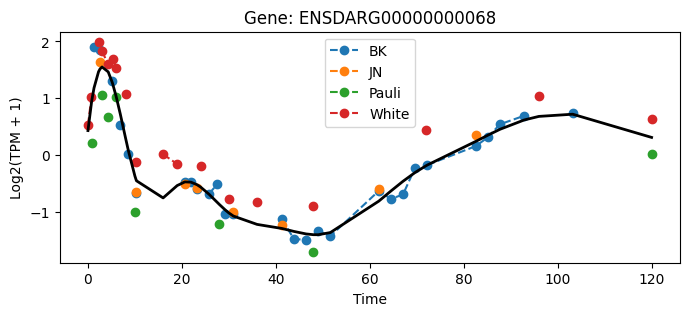

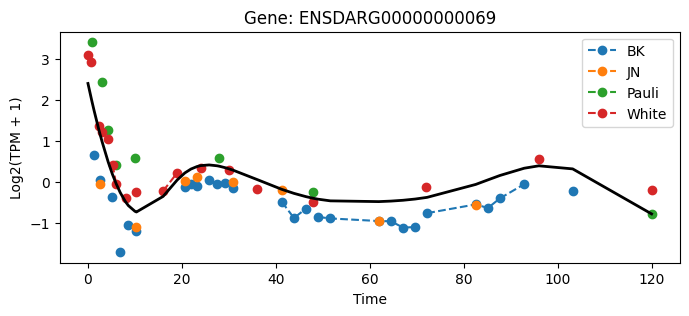

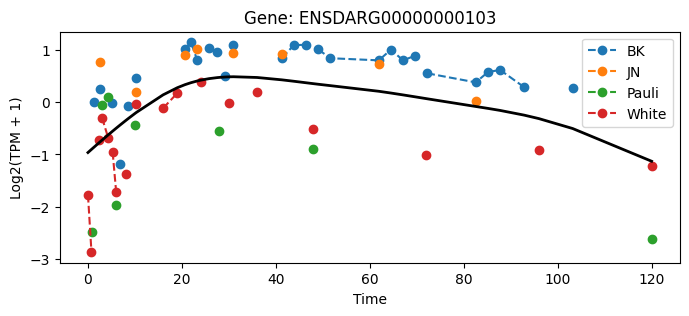

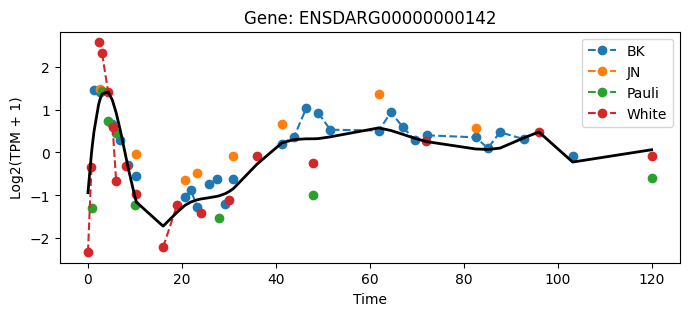

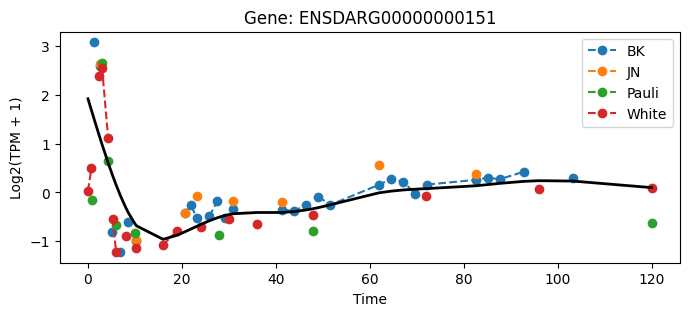

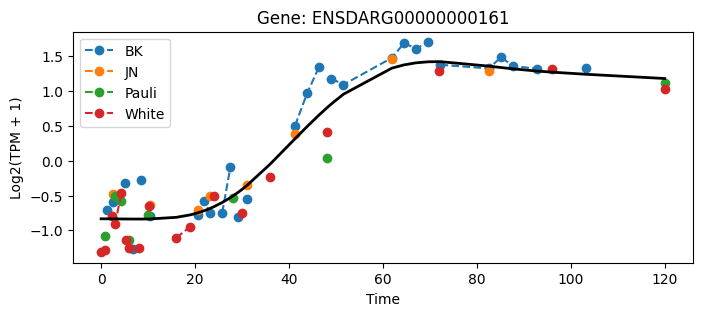

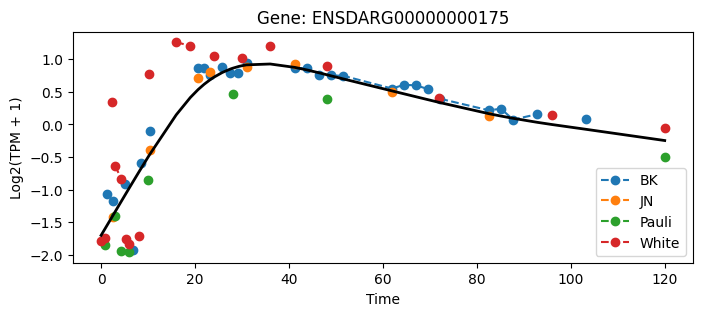

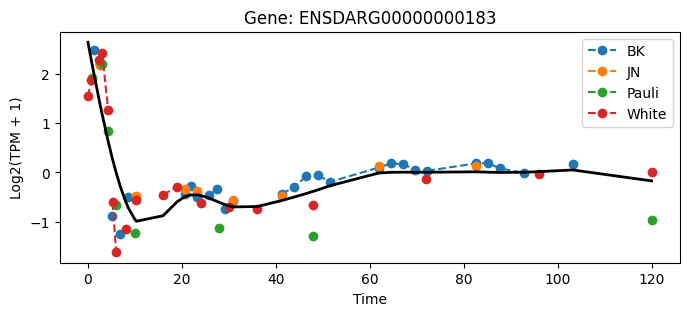

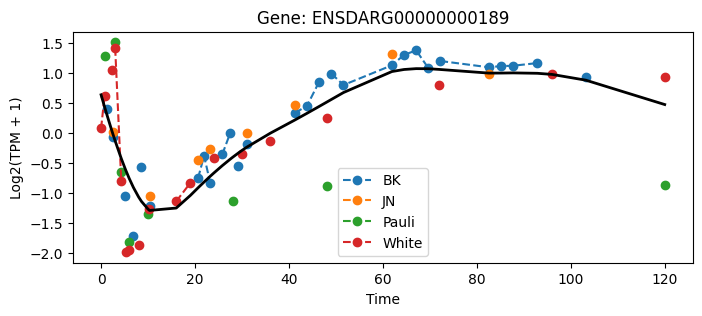

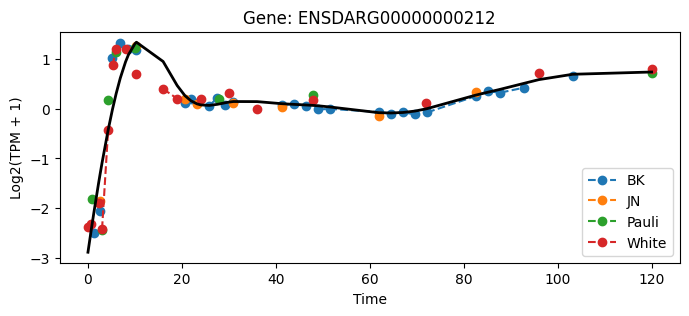

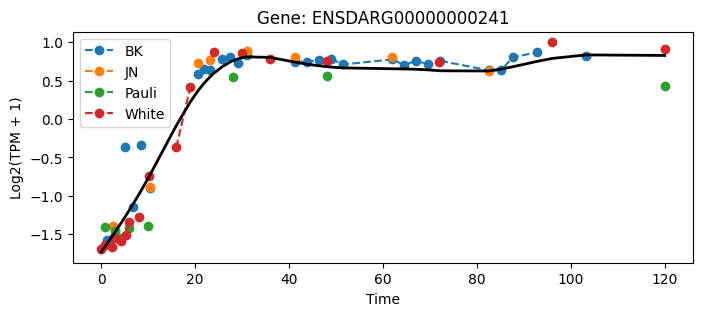

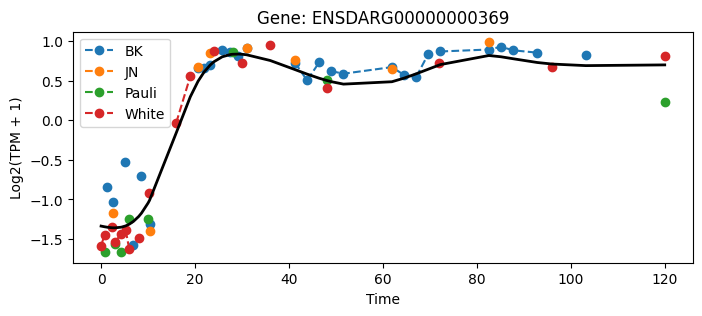

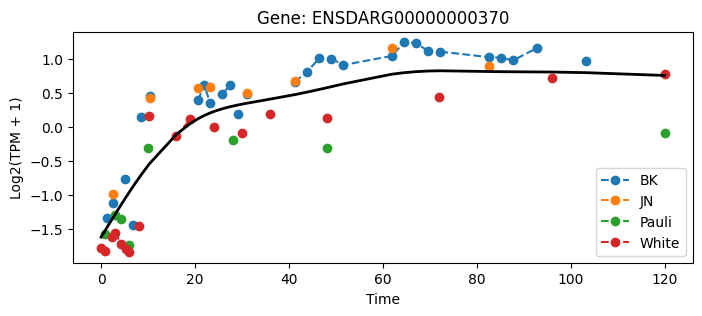

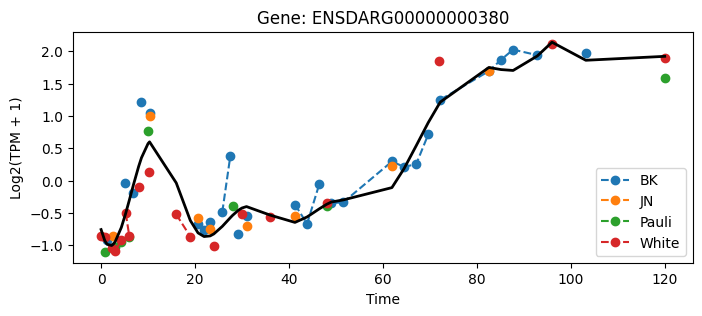

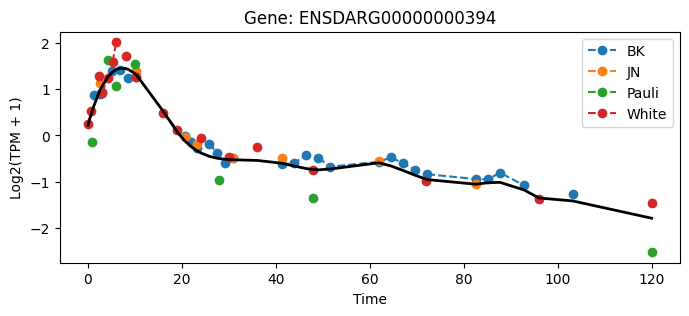

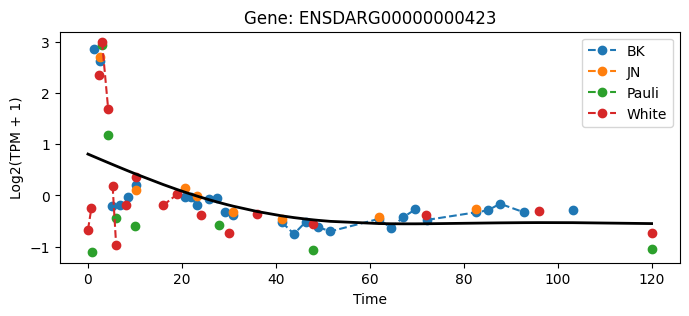

In [45]:
sc = ds.source.values

for g in accepted_genes[0:20]:
#for g in rejected_genes[0:20]:
    y_true = ds_filtered.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = traj120.sel(ensembl_gene_id=g, drop=True)
    plt.figure(figsize=(8, 3))
    plt.plot(ds_filtered.time, y_true, marker="o", ls="--", label=sc)
    plt.plot(ds_filtered.time, y_pred, "k", lw=2)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

### Cluster center GOF

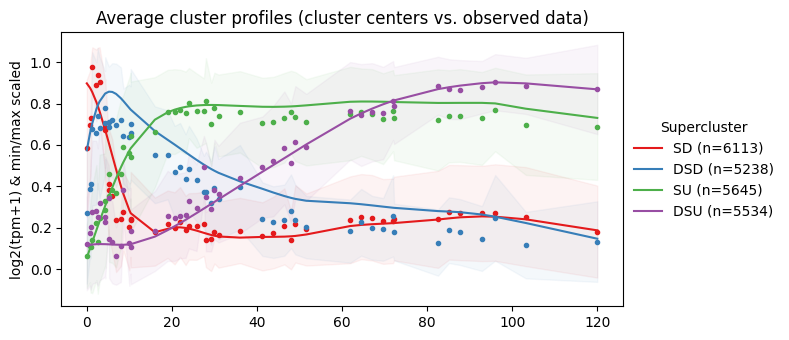

,supercluster,RMSE,r2,spearmanr,pearsonr
0,0,0.096090,0.840035,0.902137,0.919883
1,1,0.129040,0.648464,0.949580,0.965748
2,2,0.051784,0.954959,0.776038,0.985983
3,3,0.083824,0.919268,0.921441,0.973022


In [4]:
def minmax(curve):
    mn = curve.min("time")
    mx = curve.max("time")
    return (curve - mn) / (mx - mn)

def zscore(curve):
    sd = curve.std("time")
    return (curve - curve.mean("time")) / sd

def rmse(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    return np.sqrt(np.mean((a[mask] - b[mask])**2)).item()

def r2(y_true, y_pred):
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    ss_res = np.sum((y_true[mask] - y_pred[mask])**2)
    ss_tot = np.sum((y_true[mask] - np.mean(y_true[mask]))**2)
    return (1 - ss_res/ss_tot).item()

fuzzy_cntr = xr.load_dataarray("clustering/results/all_superclusters_centers.nc")
labels = xr.load_dataset(f"clustering/results/all_gene_cluster_annotation_minmax.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds["tpm"] = np.log2(ds.tpm + 1)
ds["tpm"] = (ds.tpm - ds.tpm.mean(dim=("time", "source"))) / ds.tpm.std(dim=("time", "source")) #z-score

gof = []
cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
colors = sns.color_palette("Set1", 5)

plt.figure(figsize=(8,3.5))
for c in range(fuzzy_cntr.shape[0]):

    gene_ids = labels['ensembl_gene_id'][labels['supercluster'] == c].values

    ds_c = ds.sel(ensembl_gene_id=gene_ids)
    ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
    ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id", "source"))
    #ds_c = zscore(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
    center = fuzzy_cntr[c, :]

    plt.plot(fuzzy_cntr.time, center, label=f"{cluster_map[c]} (n={ds_c.ensembl_gene_id.size})", c=colors[c])
    plt.plot(ds_c_mean.time, ds_c_mean, ".", c=colors[c])
    plt.fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=colors[c])

    gof.append({"supercluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
   
pd.DataFrame(gof).to_excel("clustering/cluster_validation.xlsx")
    
plt.title("Average cluster profiles (cluster centers vs. observed data)")
plt.ylabel("log2(tpm+1) & min/max scaled")
plt.legend(loc=(1.01, 0.3), frameon=False, title="Supercluster")
plt.tight_layout()
plt.savefig("clustering/figs/cluster_validation.png", dpi=300)
plt.show()
pd.DataFrame(gof)

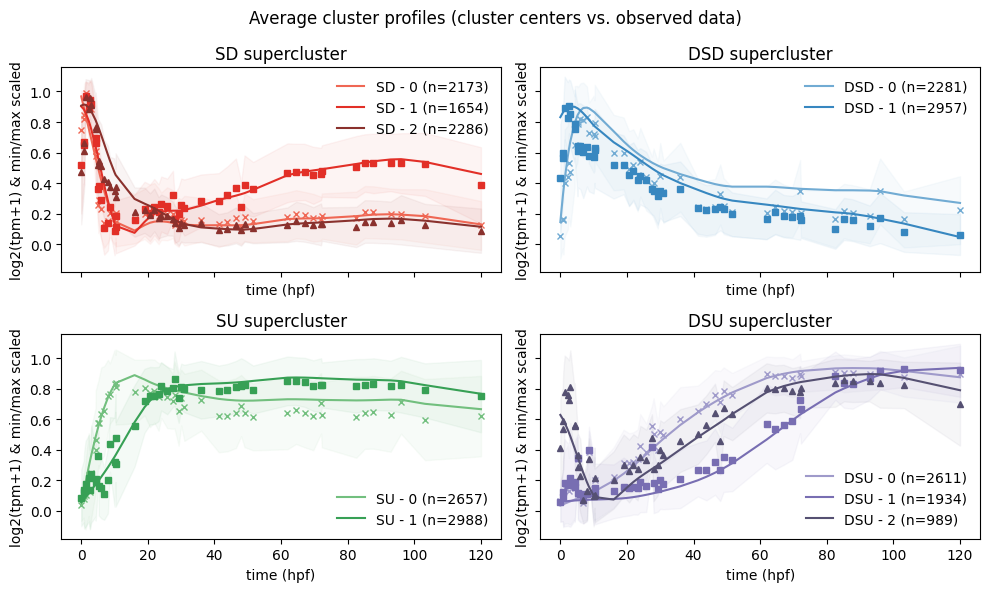

,supercluster,subcluster,RMSE,r2,spearmanr,pearsonr
0,0,0,0.089076,0.869105,0.731381,0.935927
1,0,1,0.108600,0.765513,0.891669,0.884349
2,0,2,0.117197,0.847245,0.939688,0.946022
3,1,0,0.128799,0.602357,0.943529,0.970691
4,1,1,0.147585,0.709311,0.973205,0.955637
5,2,0,0.075131,0.864788,0.912413,0.975989
6,2,1,0.058240,0.963901,0.925762,0.983326
7,3,0,0.077387,0.949186,0.939400,0.983463
8,3,1,0.097478,0.883439,0.803601,0.970014
9,3,2,0.113051,0.816407,0.914046,0.913009


In [5]:
## Subcluster Centers
labels = xr.load_dataset(f"clustering/results/all_gene_cluster_annotation_minmax.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds["tpm"] = np.log2(ds.tpm + 1)

mean = ds.tpm.mean(dim=("time", "source"))
std = ds.tpm.std(dim=("time", "source"))
ds["tpm"] = (ds.tpm - mean) / std

gof = []
cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
marker_map = {0:"x", 1:"s", 2:"^"}
colors = sns.color_palette("Set2", 5)

color_map = {0:sns.color_palette("Reds_d", 3),
             1:sns.color_palette("Blues_d", 3),
             2:sns.color_palette("Greens_d",3),
             3:sns.color_palette("Purples_d",3),}

gof=[]

fig, ax = plt.subplots(2,2, figsize= (10, 6), sharex=True, sharey=True)
ax=ax.flatten()
for k in range(4):

    #fig, ax = plt.subplots(1,1,figsize= (10, 6), squeeze=False)
    #ax=ax.flatten()
    fuzzy_cntr = xr.load_dataarray(f"clustering/results/all_supercluster_{k}_centers.nc")
    for c in range(fuzzy_cntr.shape[0]):

        gene_ids = labels['ensembl_gene_id'][(labels['supercluster'] == k) & (labels['subcluster'] == c)].values
        ds_c = ds.sel(ensembl_gene_id=gene_ids)
        ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
        ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id", "source"))

        center = fuzzy_cntr[c, :]

        ax[k].plot(fuzzy_cntr.time, center, label=f"{cluster_map[k]} - {c} (n={ds_c.ensembl_gene_id.size})", c=color_map[k][c])
        ax[k].plot(ds_c_mean.time, ds_c_mean, ls="", marker=marker_map[c], ms=4, c=color_map[k][c])
        ax[k].fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=color_map[k][c])

        gof.append({"supercluster":k, "subcluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                    "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
    
    ax[k].set(title=f"{cluster_map[k]} supercluster", ylabel= "log2(tpm+1) & min/max scaled", xlabel="time (hpf)")
    ax[k].legend(frameon=False)

plt.suptitle("Average cluster profiles (cluster centers vs. observed data)")
plt.tight_layout()
plt.savefig(f"clustering/figs/subcluster_validation.png", dpi=300)
plt.show()

pd.DataFrame(gof).to_excel("clustering/subcluster_validation.xlsx")  
pd.DataFrame(gof)

In [55]:
labels = xr.load_dataset(f"clustering/results/all_gene_cluster_annotation_minmax.nc")
labels

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 22530, time: 50, source: 4)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000069673' ... 'ENSDA...
    supercluster     (ensembl_gene_id) int32 3 0 1 3 3 0 1 1 ... 3 3 2 3 2 3 3 0
    subcluster       (ensembl_gene_id) int32 0 0 1 2 2 2 0 1 ... 2 2 0 1 1 2 1 2
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 96.0 103.2 120.0
  * source           (source) object 'BK' 'JN' 'Pauli' 'White'
Data variables:
    tpm              (time, ensembl_gene_id, source) float64 nan nan ... 5.597
Attributes:
    description:  RNA-seq data from multiple sources: White et al. (2017), Pa...
    units:        TPM

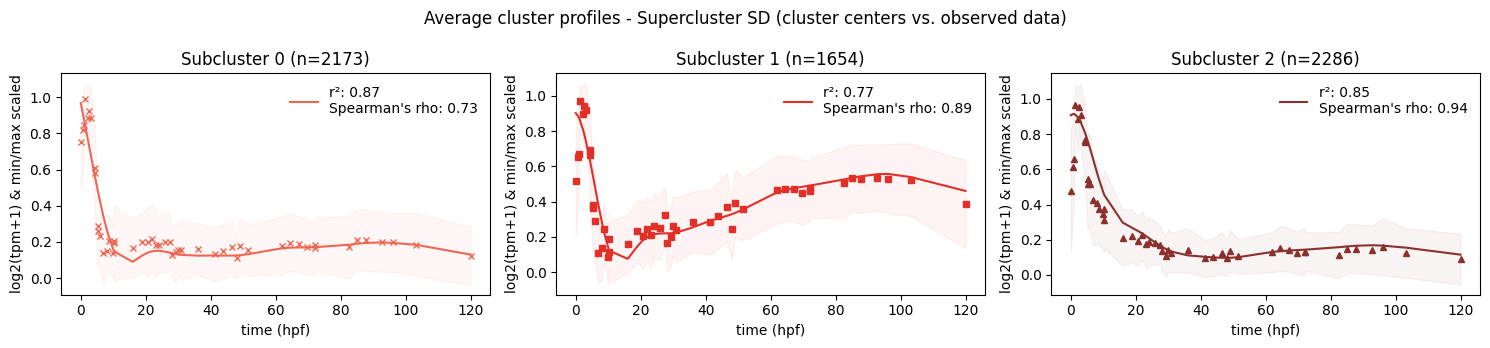

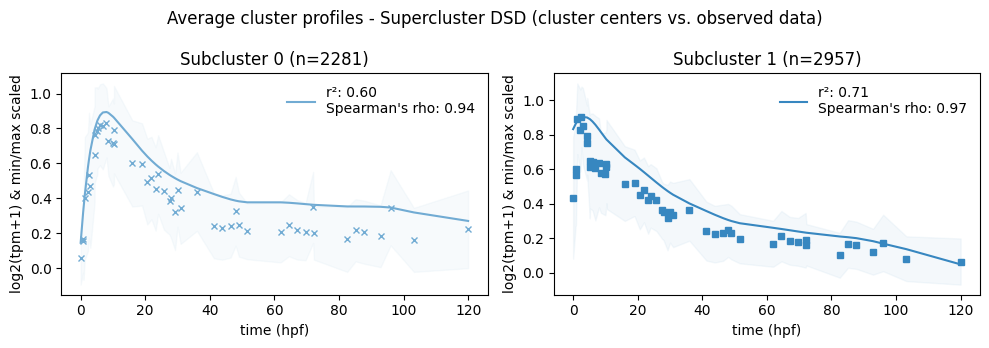

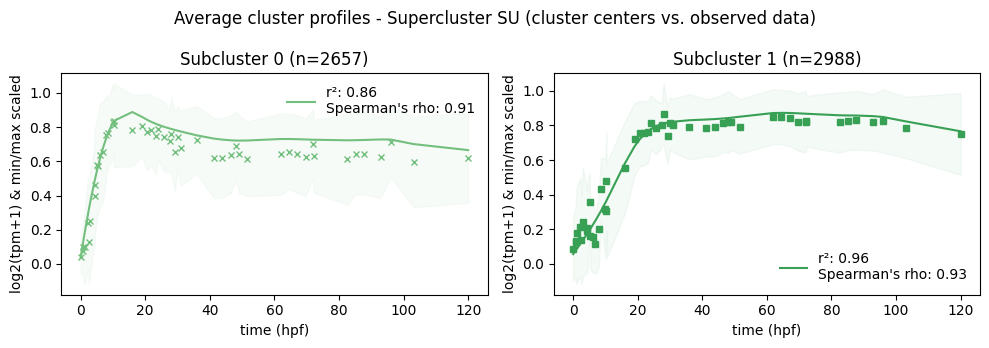

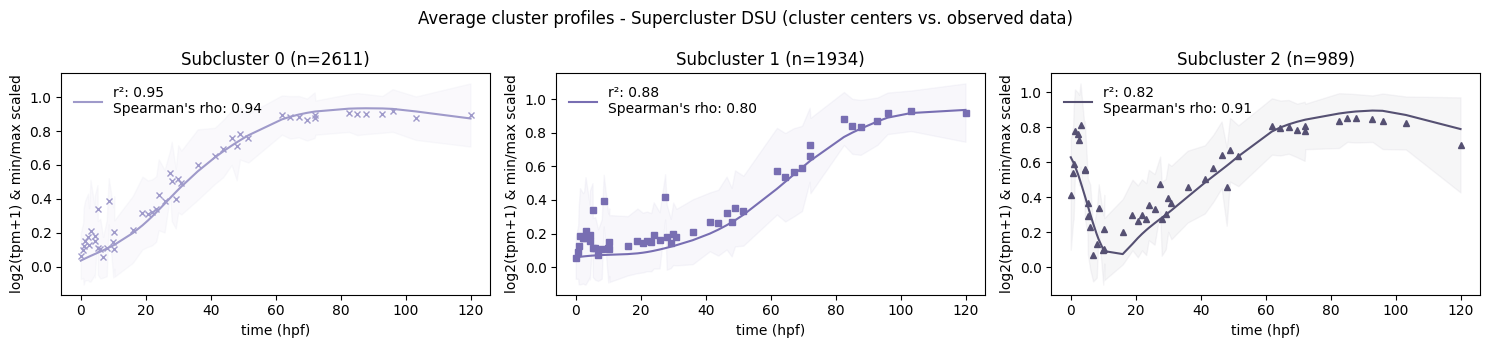

In [6]:
## Subcluster Centers
labels = xr.load_dataset(f"clustering/results/all_gene_cluster_annotation_minmax.nc")
ds = xr.load_dataset("data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds["tpm"] = np.log2(ds.tpm + 1)

mean = ds.tpm.mean(dim=("time", "source"))
std = ds.tpm.std(dim=("time", "source"))
ds["tpm"] = (ds.tpm - mean) / std

gof = []
cluster_map = {0:"SD", 1:"DSD", 2:"SU", 3:"DSU"}
marker_map = {0:"x", 1:"s", 2:"^"}
colors = sns.color_palette("Set2", 5)

color_map = {0:sns.color_palette("Reds_d", 3),
             1:sns.color_palette("Blues_d", 3),
             2:sns.color_palette("Greens_d",3),
             3:sns.color_palette("Purples_d",3),}
gof=[]

#fig, ax = plt.subplots(2,2, figsize= (10, 6), sharex=True, sharey=True)
#ax=ax.flatten()
for k in range(4):
    fuzzy_cntr = xr.load_dataarray(f"clustering/results/all_supercluster_{k}_centers.nc")
    sub_cluster = fuzzy_cntr.shape[0]
    fig, ax = plt.subplots(1,sub_cluster, figsize= (5*sub_cluster, 3.5), squeeze=False)
    ax=ax.flatten()

    for c in range(sub_cluster):
        gene_ids = labels['ensembl_gene_id'][(labels['supercluster'] == k) & (labels['subcluster'] == c)].values
        ds_c = ds.sel(ensembl_gene_id=gene_ids)
        ds_c_mean = minmax(ds_c.tpm).mean(dim=("ensembl_gene_id", "source"))
        ds_c_std = minmax(ds_c.tpm).std(dim=("ensembl_gene_id", "source"))

        center = fuzzy_cntr[c, :]

        ax[c].plot(fuzzy_cntr.time, center, 
                   label=f"r²: {r2(center, ds_c_mean):.2f} \nSpearman's rho: {spearmanr(center, ds_c_mean)[0]:.2f}", 
                   c=color_map[k][c])
        ax[c].plot(ds_c_mean.time, ds_c_mean, ls="", marker=marker_map[c], ms=4, c=color_map[k][c])
        ax[c].fill_between(ds_c_mean.time.values, ds_c_mean - ds_c_std,ds_c_mean + ds_c_std, alpha=0.05, color=color_map[k][c])

        gof.append({"supercluster":k, "subcluster":c, "RMSE":rmse(center, ds_c_mean),  "r2":r2(center, ds_c_mean),  
                    "spearmanr": spearmanr(center, ds_c_mean)[0], "pearsonr":pearsonr(center, ds_c_mean)[0]})
    
        ax[c].set(title=f"Subcluster {c} (n={ds_c.ensembl_gene_id.size})", ylabel= "log2(tpm+1) & min/max scaled", xlabel="time (hpf)")
        ax[c].legend(frameon=False)

    plt.suptitle(f"Average cluster profiles - Supercluster {cluster_map[k]} (cluster centers vs. observed data)")
    plt.tight_layout()
    plt.savefig(f"clustering/figs/subcluster_validation_{k}.png", dpi=300)
    plt.show()


## Cluster Heatmap

In [2]:
import seaborn as sns
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_heatmap_supercluster(annotation_path, cluster_col="supercluster", 
                  algo="hierarchical", source="all", norm="minmax", supercluster=None):

    # load annotated dataset (supercluster, subcluster, tpm)
    ann = xr.load_dataset(annotation_path)
    t_not = [5.16, 8.6, 27.52, 41.28]
    mask = ~ann.time.isin(t_not)
    ann = ann.sel(time=mask)

    if supercluster != None:
        ann = ann.where(ann.supercluster == supercluster, drop=True).sel(time=slice(0, 120))

    # select expression data: average over source, or pick one if specified
    if "source" in ann.tpm.dims:
        if source != "all":
            ann = ann.sel(source=source, drop=True)
            ann = ann.dropna(dim="time", how="all", subset=["tpm"])
            tpm = ann.tpm
        else:
            tpm = ann.tpm.mean(dim="source", skipna=True)
    else:
        tpm = ann.tpm

    tpm = tpm.transpose("ensembl_gene_id", "time")

    # drop genes with no valid time points
    valid = np.isfinite(tpm).any(dim="time")
    tpm = tpm.sel(ensembl_gene_id=valid)
    ann = ann.sel(ensembl_gene_id=tpm.ensembl_gene_id)

    # normalise per gene, same scheme as in fuzzy_cmeans
    tpm = np.log2(tpm+1)

    if norm == "minmax":
        X_z = (tpm - tpm.min("time")) / (tpm.max("time") - tpm.min("time"))
    elif norm == "zscore":
        X_z = (tpm - tpm.mean("time")) / tpm.std("time")
        
    elif norm == "meanmax":
        dev = tpm - tpm.mean("time")
        denom = abs(dev).max("time")
        denom = denom.where(denom > 0)
        X_z = dev / denom
    else:
        print("[ERROR] Provide valid normalisation method (minmax, meanmax)")
        return

    still_valid = np.isfinite(X_z).any(dim="time")
    print(f"[debug] genes surviving normalisation: {int(still_valid.sum())} / {still_valid.size}")

    X_z = X_z.sel(ensembl_gene_id=still_valid)
    ann = ann.sel(ensembl_gene_id=X_z.ensembl_gene_id)

    if X_z.sizes["ensembl_gene_id"] == 0:
        raise ValueError(
            f"No genes remain after filtering for source={source!r}. "
            "Check that this source has enough non-NaN time points per gene."
        )

    # cluster labels
    clusters = ann[cluster_col].values

    # time axis (index of max expression per gene)
    time_idx = X_z.argmax(dim="time", skipna=True).values

    # build structured sort: first cluster, then peak time
    sorted_genes = np.lexsort((time_idx, clusters))
    expr_plot = X_z.isel(ensembl_gene_id=sorted_genes)
    sorted_clusters = clusters[sorted_genes]

    # unique clusters in sorted order
    unique_clusters, start_idx = np.unique(sorted_clusters, return_index=True)
    end_idx = np.r_[start_idx[1:], len(sorted_clusters)]
    centers = (start_idx + end_idx) / 2

    cluster_cmap = ListedColormap(sns.color_palette("Set1", len(np.unique(clusters))))

    fig = plt.figure(figsize=(8, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[0.015, 1], wspace=0.01)

    # Cluster bar (left)
    ax_bar = fig.add_subplot(gs[0])
    ax_bar.imshow(sorted_clusters[:, None], aspect='auto', cmap=cluster_cmap)
    ax_bar.set_xticks([])
    ax_bar.set_yticks([])

    for c, y in zip(unique_clusters, centers):
        ax_bar.text(0.05, y, str(c),
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='black',
                    transform=ax_bar.transData)

    # Heatmap
    ax = fig.add_subplot(gs[1])
    sns.heatmap(expr_plot.values,
                cmap='Spectral_r',
                yticklabels=False, xticklabels=expr_plot.time.values,
                ax=ax, cbar_kws={'label': 'expression', 'shrink': 0.5, 'pad': 0.02})

    if supercluster != None:
        ax.set_title(f'Gene expression pattern in $D. rerio$ \n Cluster {supercluster}, n={int(still_valid.sum())} ({algo}, {source})', fontsize=12) 
    else:
        ax.set_title(f'Gene expression pattern in $D. rerio$ ({algo}, {source})', fontsize=12) 

    ax.set(xlabel='time (hpf)', ylabel='')

    ax.vlines(3.5, *ax.get_ylim(), colors='k', linewidth=1, ls='--')

    # Find cluster boundaries
    boundaries = np.where(np.diff(sorted_clusters) != 0)[0]
    for b in boundaries:
        ax.hlines(b, *ax.get_xlim(), colors='k', linewidth=1.5)

    plt.tight_layout()
    plt.savefig(f"clustering/figs/{algo}_cluster_heatmap_{source}_{cluster_col}_{supercluster}.png",
                dpi=300, transparent=True)
    plt.show()

[debug] genes surviving normalisation: 22530 / 22530


C:\Users\mgrho\AppData\Local\Temp\ipykernel_21236\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


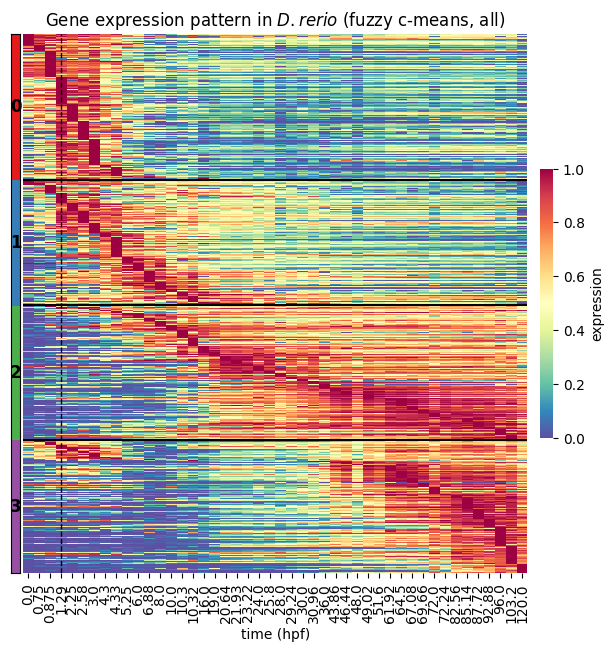

In [3]:
plot_heatmap_supercluster("clustering/results/all_gene_cluster_annotation_minmax.nc", cluster_col="supercluster", algo="fuzzy c-means", norm="minmax",)

[debug] genes surviving normalisation: 6113 / 6113


C:\Users\mgrho\AppData\Local\Temp\ipykernel_1408\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


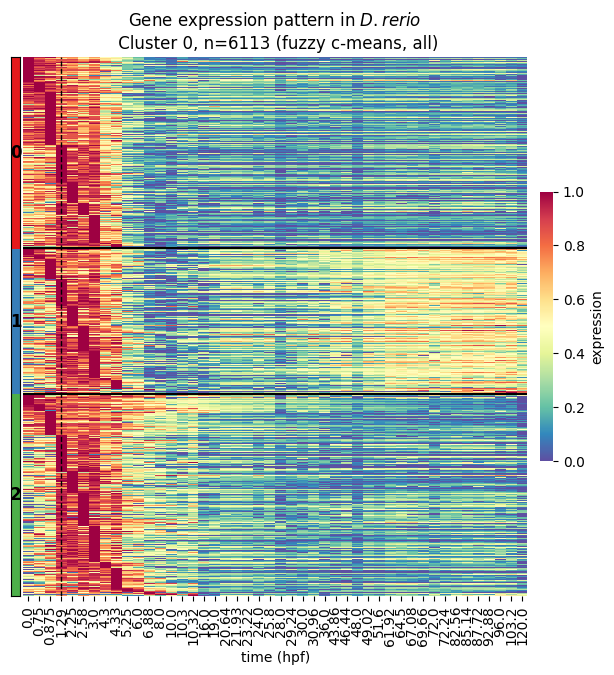

[debug] genes surviving normalisation: 5238 / 5238


C:\Users\mgrho\AppData\Local\Temp\ipykernel_1408\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


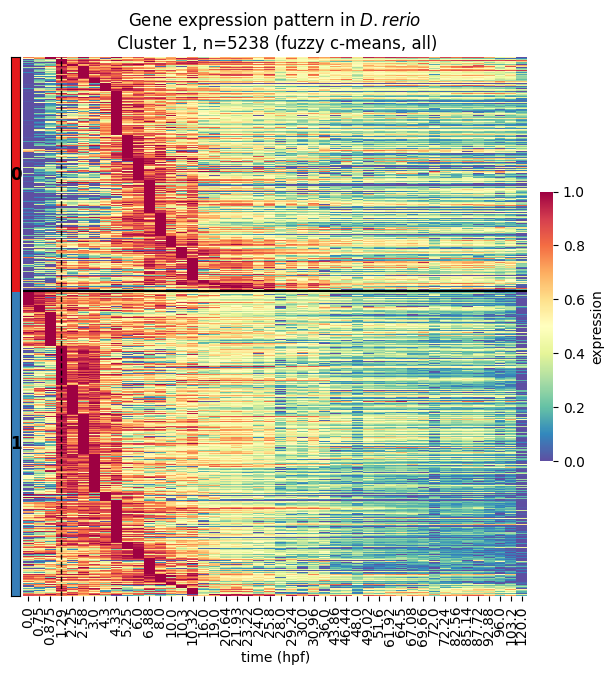

[debug] genes surviving normalisation: 5645 / 5645


C:\Users\mgrho\AppData\Local\Temp\ipykernel_1408\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


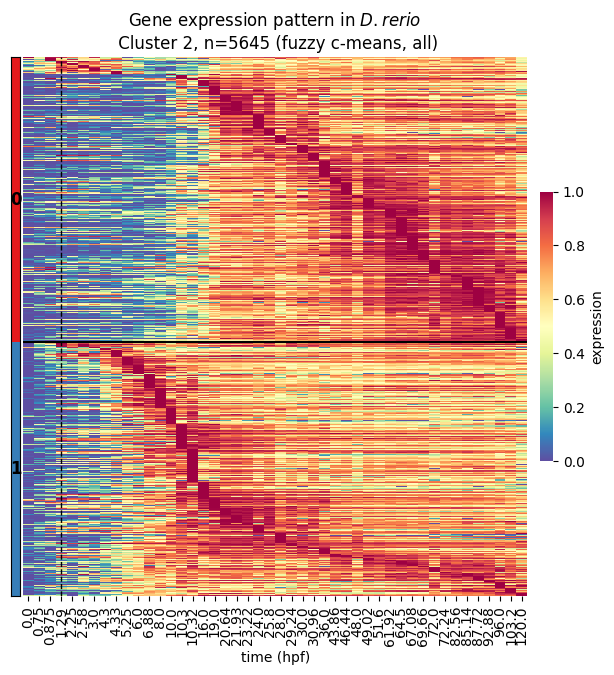

[debug] genes surviving normalisation: 5534 / 5534


C:\Users\mgrho\AppData\Local\Temp\ipykernel_1408\2644034195.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


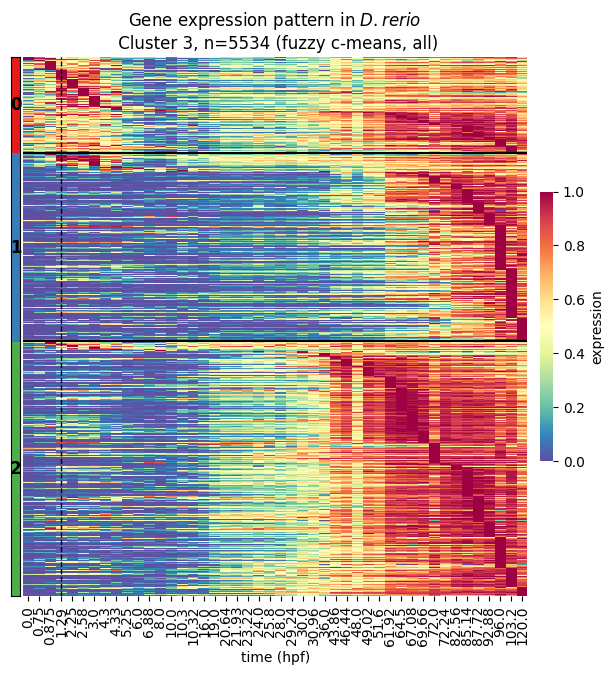

In [7]:
for i in range(4):
    plot_heatmap_supercluster("clustering/results/all_gene_cluster_annotation_minmax.nc", cluster_col="subcluster",
                algo="fuzzy c-means", source="all", supercluster=i)

## Model fit GOF

In [5]:
gof = pd.read_csv("results/results_summary/gof_all_combined.csv")
gof_src = pd.read_csv("results/results_summary/gof_src_combined.csv")
params = pd.read_csv("results/results_summary/params_combined.csv")
params.head()

,gene_id,beta_mean,delta_mean,sigma_y_mean,beta_std,delta_std,sigma_y_std,supercluster,supercluster_no,subcluster_no,...,delta_z_mean,t_reg_mean,t_rep_mean,t_zga_mean,alpha_std,delta_m_std,delta_z_std,t_reg_std,t_rep_std,t_zga_std
0,ENSDARG00000000001,0.243,0.11800,0.498,0.2120,0.09420,0.0447,SD,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ENSDARG00000000002,0.172,0.00851,0.420,0.0198,0.00368,0.0395,DSU,3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENSDARG00000000018,30.600,1.01000,0.536,9.4400,0.31500,0.0504,DSD,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ENSDARG00000000019,7.610,0.16000,0.266,1.3900,0.02610,0.0245,SD,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ENSDARG00000000068,0.976,0.10000,0.640,0.3540,0.03030,0.0581,SD,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


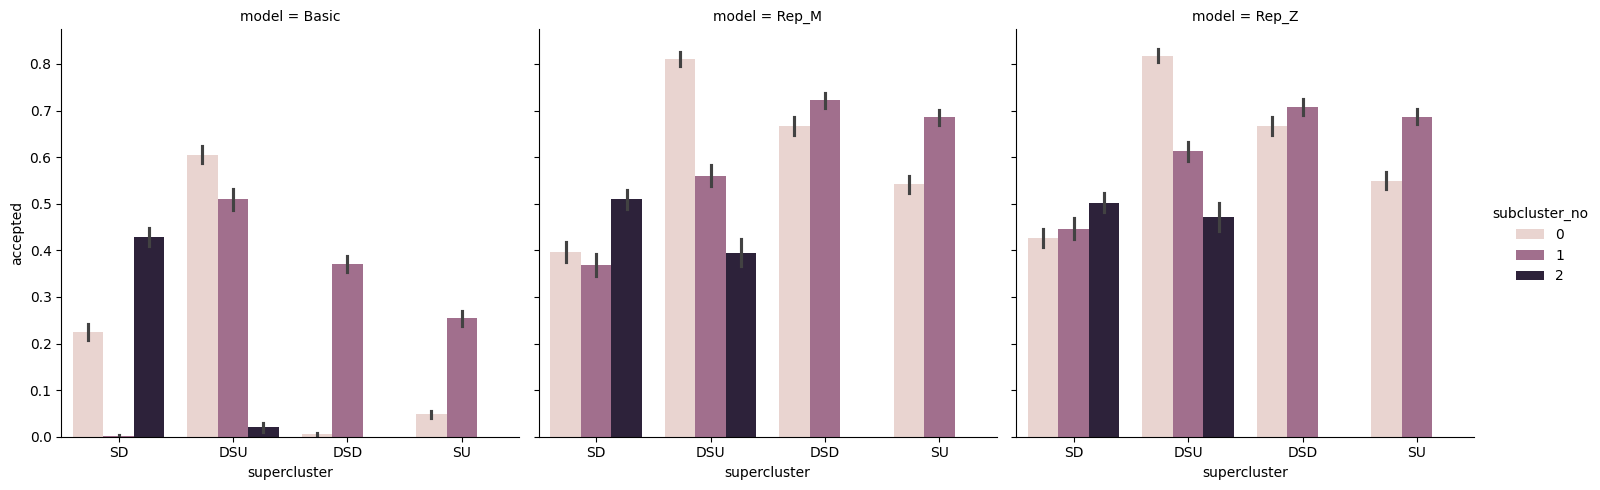

In [6]:
gof["accepted"] = (gof["rho"] > 0.7) & (gof["NRMSE"] < 0.3)
sns.catplot(gof, x ="supercluster", y="accepted", hue="subcluster_no", col="model", kind="bar", estimator="mean")

In [32]:
# result summary
with pd.ExcelWriter("results/evaluation_all.xlsx") as writer:
    gof.groupby(["model", "supercluster"])[["BIC", "rho", "NRMSE"]].median().round(2).to_excel(writer, sheet_name="median_all")
    gof.groupby(["model", "supercluster"])[["BIC", "rho", "NRMSE"]].quantile([0.05, 0.95]).round(2).to_excel(writer, sheet_name="percentile_all")
    gof_src.groupby(["model", "source"])[["BIC", "rho", "NRMSE"]].median().round(2).to_excel(writer, sheet_name="median_src")
    gof_src.groupby(["model", "source"])[["BIC", "rho", "NRMSE"]].quantile([0.05, 0.95]).round(2).to_excel(writer, sheet_name="percentile_src")
    gof_src.groupby(["model", "source", "supercluster"])[["BIC", "rho", "NRMSE"]].median().round(2).to_excel(writer, sheet_name="median_sc_src")
    gof_src.groupby(["model", "source", "supercluster"])[["BIC", "rho", "NRMSE"]].quantile([0.05, 0.95]).round(2).to_excel(writer, sheet_name="percentile_sc_src")


In [9]:
ds = xr.load_dataset("clustering/results/all_gene_cluster_annotation_minmax.nc").tpm.mean("source")
df = pd.DataFrame({"ensembl_gene_id": ds.ensembl_gene_id.values,
                   "supercluster_no":ds.supercluster.values,
                   "subluster_no":ds.subcluster.values,})
stats = xr.Dataset({"t_peak": ds.idxmax(dim="time"),})

stats_df = stats.to_dataframe().reset_index().drop(columns=["supercluster", "subcluster"])
df = df.merge(stats_df, on="ensembl_gene_id", how="left")

time = ds.time.values

In [10]:
# load data and combine with supercluster assignment
gof_all = pd.read_csv("results/results_summary/gof_all_combined.csv")
gof_src = pd.read_csv("results/results_summary/gof_src_combined.csv")
params = pd.read_csv("results/results_summary/params_combined.csv")
supercluster = xr.load_dataset("clustering/results/all_gene_cluster_annotation_minmax.nc")

# Build a lookup table from the DataArray's coordinates
lookup = pd.DataFrame({
    "ensembl_gene_id": supercluster["ensembl_gene_id"].values,
    "supercluster_no": supercluster["supercluster"].values,
    "subcluster_no": supercluster["subcluster"].values,
}).set_index("ensembl_gene_id")

cluster_names = {0 : "SD", 1 : "DSD", 2 : "SU", 3 : "DSU"}
lookup["supercluster"]=lookup["supercluster_no"].map(cluster_names)

# Map onto df by gene_id
for df in [gof_all, gof_src, params]:
    df["supercluster"] = df["gene_id"].map(lookup["supercluster"])
    df["supercluster_no"] = df["gene_id"].map(lookup["supercluster_no"])
    df["subcluster_no"] = df["gene_id"].map(lookup["subcluster_no"])

gof_all.head()

,gene_id,NRMSE,NRMSE_lower,NRMSE_upper,LogLik,LogLik_lower,LogLik_upper,BIC,BIC_lower,BIC_upper,rho,pearsonr,WAIC,LOO,supercluster,supercluster_no,subcluster_no,model
0,ENSDARG00000000001,0.247397,0.207575,0.287312,-44.491680,-46.439812,-43.397228,101.364765,99.175860,105.261027,0.072557,0.569631,-47.244569,-47.368093,SD,0,0,Basic
1,ENSDARG00000000002,0.270265,0.176917,0.384435,-33.462400,-36.746632,-30.898830,79.306205,74.179064,85.874666,0.908860,0.947476,-35.081911,-35.113083,DSU,3,0,Basic
2,ENSDARG00000000018,0.304176,0.238389,0.386343,-49.140537,-52.698807,-46.312111,110.662477,105.005625,117.779017,-0.510609,0.085448,-50.931778,-50.956989,DSD,1,1,Basic
3,ENSDARG00000000019,0.213511,0.167638,0.259818,-4.288596,-6.666051,-2.738154,20.958594,17.857712,25.713505,0.391405,0.815170,-5.698864,-5.719403,SD,0,1,Basic
4,ENSDARG00000000068,0.299493,0.235036,0.379914,-60.592080,-62.927002,-59.135445,133.565563,130.652292,138.235407,0.408115,0.696970,-61.588580,-61.596542,SD,0,1,Basic


In [66]:
print(np.percentile(gof_all[gof_all["model"]=="Basic"].BIC, (5,95)))
print(np.percentile(gof_all[gof_all["model"]=="Rep_M"].BIC, (5,95)))
print(np.percentile(gof_all[gof_all["model"]=="Rep_Z"].BIC, (5,95)))

[  6.70865533 190.59530319]
[-19.53985853 156.48638469]
[-17.9872995 156.3797211]


In [54]:
gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")


basic_bic = gof_all[gof_all["model"] == "Basic"].set_index("gene_id")["BIC"]
gof_all["delta_BIC"] = gof_all["BIC"] - gof_all["gene_id"].map(basic_bic)
gof_all[gof_all["delta_BIC"] < -6].value_counts("model") / 22530

model
Rep_Z    0.716644
Rep_M    0.671105
Name: count, dtype: float64

In [57]:
gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")
best_models = gof_all[gof_all["BIC_rank"] == 1]
best_models.value_counts("model") / 22530

model
Rep_Z    0.446427
Rep_M    0.369285
Basic    0.184288
Name: count, dtype: float64

C:\Users\mgrho\AppData\Local\Temp\ipykernel_12184\1486746792.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(best_models, x="model", palette=mod_color_dict, order=model_order)


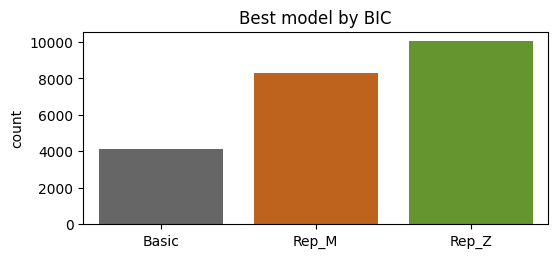

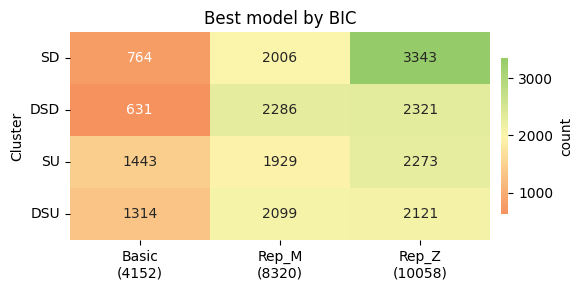

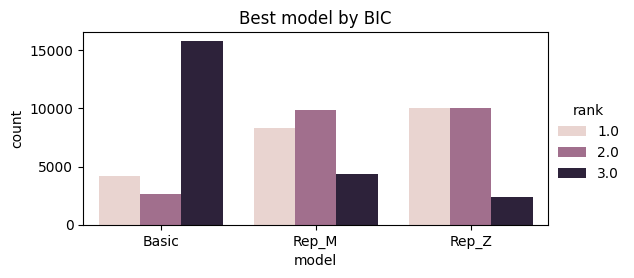

In [33]:
metr = "BIC"
best_models = gof_all.loc[gof_all.groupby("gene_id")[metr].idxmin()]
counts = pd.crosstab(best_models["model"], best_models["supercluster"])
counts = counts[["SD", "DSD", "SU", "DSU"]].T

labels = [f"{i}\n({counts[i].sum()})" for i in counts.columns]

fig = plt.figure(figsize=(6,2.5))
sns.countplot(best_models, x="model", palette=mod_color_dict, order=model_order)
plt.title(f"Best model by {metr}")
plt.xlabel("")
plt.savefig(f"results/figures/best_by_{metr}.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
sns.heatmap(counts, annot=True, fmt="d", cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True),
            cbar_kws={'label': 'count', 'shrink': 0.75, 'pad': 0.02 }, alpha=0.8, ax=ax)

ax.set(xlabel="", title=f"Best model by {metr}", ylabel="Cluster")
plt.yticks(rotation=0)
ax.set_xticklabels(labels)
plt.tight_layout()
plt.savefig(f"results/figures/best_by_{metr}_cluster.png", dpi=300)
plt.show()

#best_models = gof_all.loc[gof_all.groupby("gene_id")["BIC"].idxmin()]
gof_all["BIC_rank"] = gof_all.groupby("gene_id")["BIC"].rank(method="min")
best_models = gof_all[gof_all["BIC_rank"] == 1]

fig = plt.figure(figsize=(6,2.5))
sns.countplot(gof_all, x="model", hue="BIC_rank")
plt.title("Best model by BIC")
plt.savefig("results/figures/best_by_bic.png", dpi=300)
plt.legend(loc=(1.01, 0.2), frameon=False, title="rank")
plt.show()

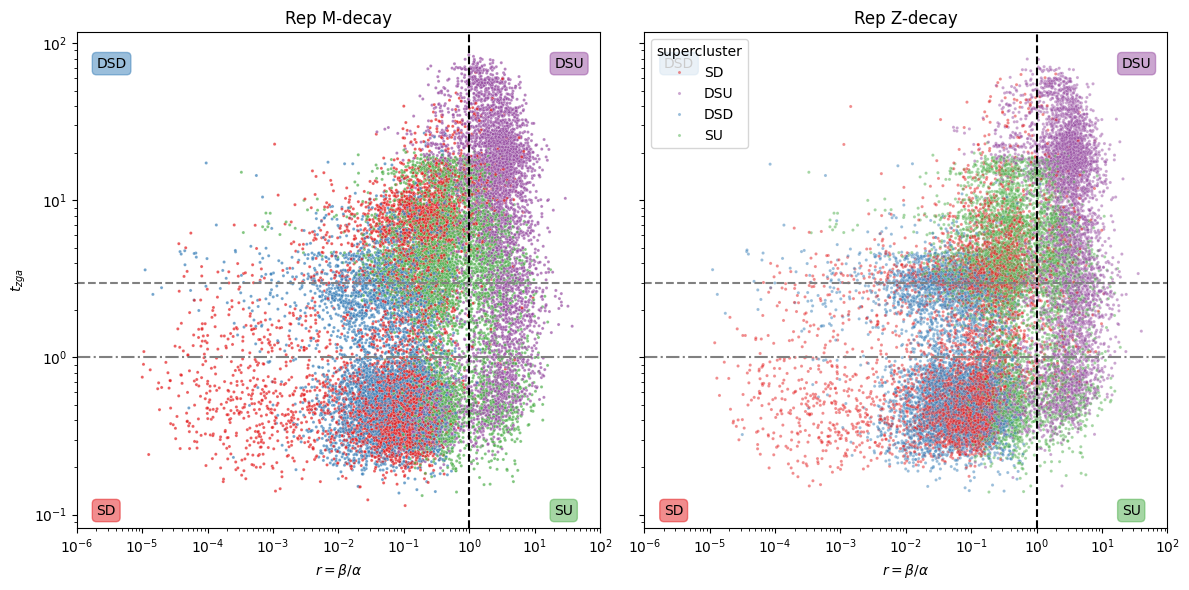

In [120]:
col_c = sns.color_palette("Set1", n_colors=4)  
cluster_color_dict = {"SD": col_c[0], "DSD": col_c[1], "SU": col_c[2], "DSU": col_c[3], }

df = params[params["model"] != "Basic"].copy()
df["r"] = df["beta_mean"] / df["alpha_mean"]
df = df[(df["r"] > 1e-5) & (df["t_zga_mean"] < 120)]

df_z = df[df["model"] == "Rep_Z"].copy()
df_m = df[df["model"] == "Rep_M"].copy()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 6), sharex=True, sharey=True)
sns.scatterplot(df_m, x="r", y="t_zga_mean", ax=ax1,  hue="supercluster", s=5, palette=cluster_color_dict, alpha=0.7, legend=False)
sns.scatterplot(df_z, x="r", y="t_zga_mean", ax=ax2, hue="supercluster", s=5, palette=cluster_color_dict, alpha=0.5, legend=True)

#sns.kdeplot(df_m, x="r", y="t_zga_mean",  hue="supercluster", ax=ax1, palette=cluster_color_dict, legend=True, log_scale=True, fill=False, levels=4)
#sns.kdeplot(df_z, x="r",  y="t_zga_mean", hue="supercluster", ax=ax2, palette=cluster_color_dict, legend=True, log_scale=True, fill=False, levels=4)

ax1.set(xlabel= "$r = \\beta / \\alpha$", ylabel="$t_{zga}$", title="Rep M-decay", xscale="log", yscale="log", xlim=(1e-6, 1e2), )
ax2.set(xlabel="$r = \\beta / \\alpha$", ylabel="$t_{zga}$", title="Rep Z-decay", xscale="log", yscale="log", xlim=(1e-6, 1e2), )

ax1.axvline(1, c="k", ls="--")
ax2.axvline(1, c="k", ls="--")
ax1.axhline(3, c="gray", ls="--", label="ZGA")
ax2.axhline(3, c="gray", ls="--", label="ZGA")
ax1.axhline(1, c="gray", ls="-.", label="ZGA")
ax2.axhline(1, c="gray", ls="-.", label="ZGA")

ax1.text(x=2e-6, y=7e1, s="DSD", bbox={"color":cluster_color_dict["DSD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e-6, y=1e-1, s="SD", bbox={"color":cluster_color_dict["SD"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=7e1, s="DSU", bbox={"color":cluster_color_dict["DSU"], "alpha":0.5, "boxstyle":"round"})
ax1.text(x=2e1, y=1e-1, s="SU", bbox={"color":cluster_color_dict["SU"], "alpha":0.5, "boxstyle":"round"})

ax2.text(x=2e-6, y=7e1, s="DSD", bbox={"color":cluster_color_dict["DSD"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e-6, y=1e-1, s="SD", bbox={"color":cluster_color_dict["SD"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e1, y=7e1, s="DSU", bbox={"color":cluster_color_dict["DSU"], "alpha":0.5, "boxstyle":"round"})
ax2.text(x=2e1, y=1e-1, s="SU", bbox={"color":cluster_color_dict["SU"], "alpha":0.5, "boxstyle":"round"})

plt.tight_layout()
plt.show()

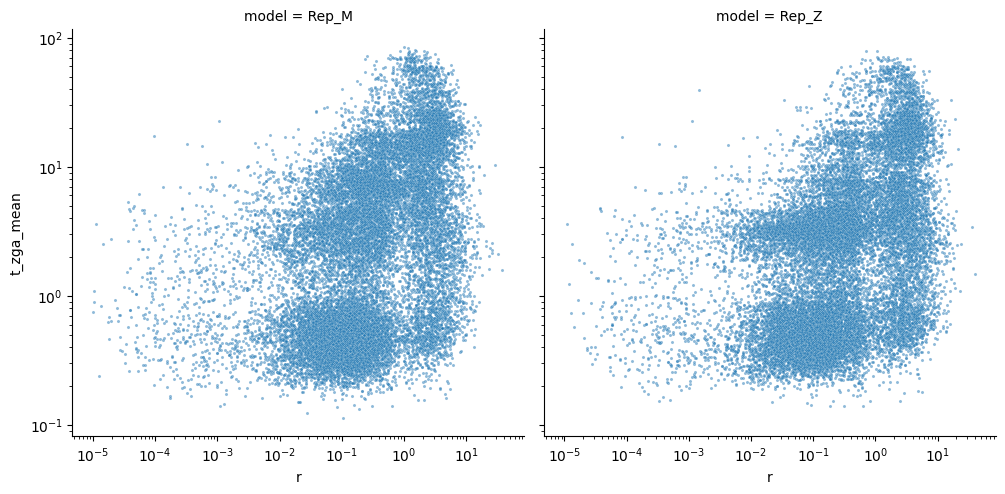

In [121]:
sns.relplot(df, x="r", y="t_zga_mean", col="model", s=5, alpha=0.5, legend=True)
plt.xscale("log")
plt.yscale("log")

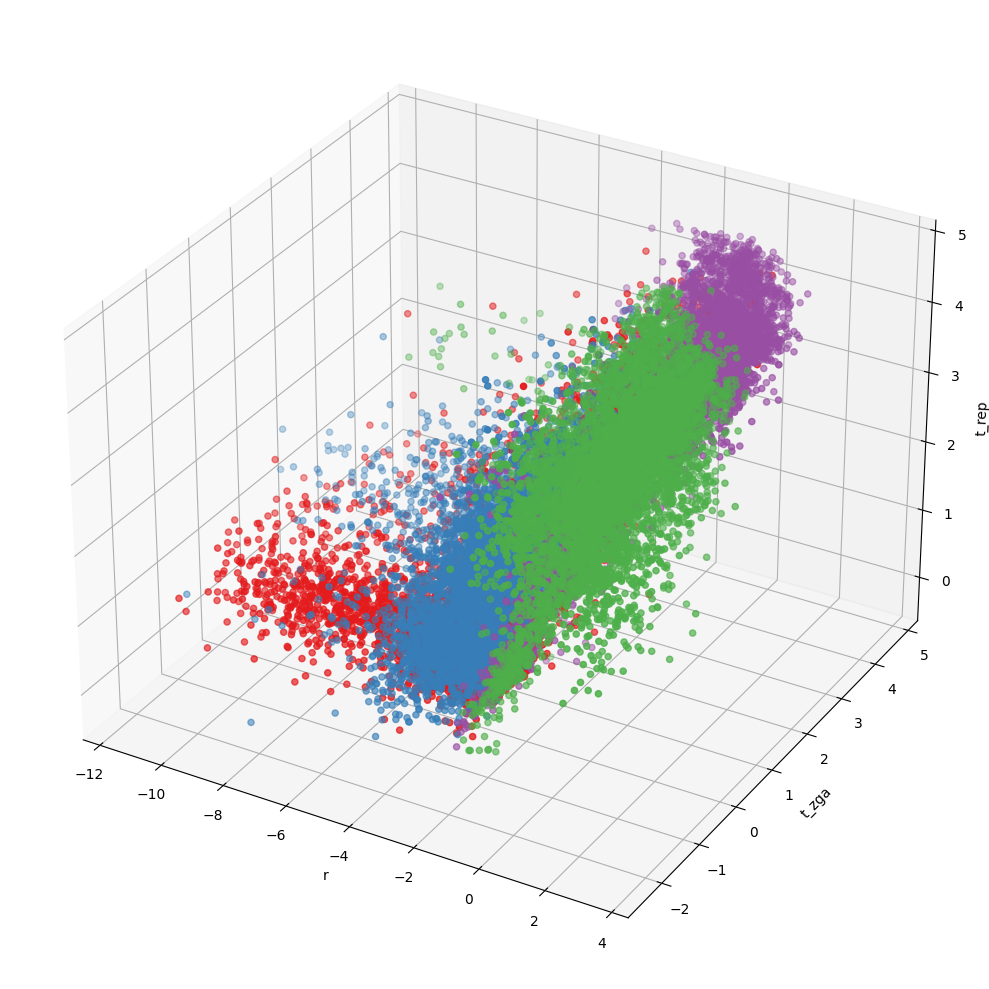

In [19]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='3d')

df = params[params["model"] != "Basic"].copy()
df["r"] = df["beta_mean"] / df["alpha_mean"]
df = df[(df["r"] > 1e-5) & (df["t_zga_mean"] < 120) & (df["t_rep_mean"] < 120)]

df_z = df[df["model"] == "Rep_Z"].copy()
df_m = df[df["model"] == "Rep_M"].copy()


df_m = df_m.dropna(subset=["supercluster"])

df_m["r"] = np.log(df_m["r"])
df_m["t_zga_mean"] = np.log(df_m["t_zga_mean"])
df_m["t_rep_mean"] = np.log(df_m["t_rep_mean"])

for sc in df_m.supercluster.unique():
    df_m1 = df_m[df_m["supercluster"] == sc].copy()
    ax.scatter(df_m1["r"], df_m1["t_zga_mean"], df_m1["t_rep_mean"], color=cluster_color_dict[sc], label=sc)
       
ax.set_xlabel('r')
ax.set_ylabel('t_zga')
ax.set_zlabel('t_rep')
plt.tight_layout()
plt.show()

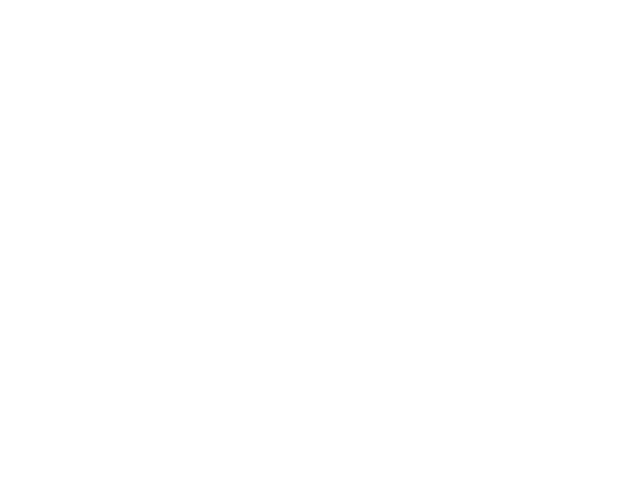

In [ ]:
# importing required libraries
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = Axes3D(fig)

for sc in df_m.supercluster.unique():
    df_m1 = df_m[df_m["supercluster"] == sc].copy()
    plot = ax.scatter(df_m1["r"].values, df_m1["t_zga_mean"].values, df_m1["t_rep_mean"].values, color=cluster_color_dict[sc])
plt.show()

In [16]:
from upsetplot import plot
from matplotlib import pyplot
from upsetplot import from_memberships


gof_src
example = from_memberships(
    [[],
     ['mase'],
     ['rho'],
     ['mase', 'rho'],
     ['nrmse'],
     ['mase', 'nrmse'],
     ['rho', 'nrmse'],
     ['mase', 'rho', 'nrmse'],
     ],
     data=[56, 283, 279, 582, 24, 90, 429, 157]
)

plot(example)

ModuleNotFoundError: No module named 'upsetplot'